<a href="https://colab.research.google.com/github/Snehamn24/PhonePe-ML-model/blob/main/PhonePe_ML_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Phonepe Transaction insights



##### **Project Type**    - Regression and EDA
##### **Contribution**    - Individual
##### **Sneha M N**

# **Project Summary -**

This project focuses on analyzing PhonePe digital transaction data to uncover meaningful insights related to user behavior, transaction trends, and geographical distribution. The dataset, obtained from the PhonePe Pulse GitHub repository, consists of structured JSON files categorized into aggregated, map, and top-level data.


A basic machine learning regression model will be implemented to predict transaction amounts based on factors like year, quarter, and transaction count. This helps in understanding future transaction trends

The data was extracted and transformed into a structured tabular format using Python. Exploratory Data Analysis (EDA) techniques were applied to understand patterns such as top-performing states, popular transaction categories, and growth trends over time. Various visualizations like bar charts, line graphs, and heatmaps were used to effectively represent the findings.

The insights derived from this project can assist businesses in making data-driven decisions related to marketing strategies, user engagement, and product development in the digital payments domain.

# **GitHub Link -**

https://github.com/Snehamn24/PhonePe-ML-model.git

# **Problem Statement**


This project analyzes PhonePe transaction data using aggregated state-level datasets to understand transaction trends, user behavior, and insurance patterns. The analysis is performed using Python, SQL, and Streamlit to derive insights on state-wise performance, transaction categories, device usage, and growth trends over time.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [122]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### GitHub Cloning

In [123]:
!git clone https://github.com/PhonePe/pulse.git

fatal: destination path 'pulse' already exists and is not an empty directory.


## Dataset Loading

In [124]:
#dataset loading

#Aggregated Transaction
import json, os, pandas as pd

data_list = []

path = "pulse/data/aggregated/transaction/country/india/state"

for state in os.listdir(path):
    for year in os.listdir(os.path.join(path, state)):
        for file in os.listdir(os.path.join(path, state, year)):
            with open(os.path.join(path, state, year, file)) as f:
                data = json.load(f)
                try:
                    for item in data["data"]["transactionData"]:
                        for inst in item["paymentInstruments"]:
                            data_list.append([
                                state, int(year), int(file.strip(".json")),
                                item["name"], inst["count"], inst["amount"]
                            ])
                except:
                    continue

df_trans = pd.DataFrame(data_list, columns=[
    "state","year","quarter","type","count","amount"
])

In [125]:
# Aggregated User
data_list = []

path = "pulse/data/aggregated/user/country/india/state"

for state in os.listdir(path):
    for year in os.listdir(os.path.join(path, state)):
        for file in os.listdir(os.path.join(path, state, year)):
            with open(os.path.join(path, state, year, file)) as f:
                data = json.load(f)
                try:
                    for item in data["data"]["usersByDevice"]:
                        data_list.append([
                            state, int(year), int(file.strip(".json")),
                            item["brand"], item["count"], item["percentage"]
                        ])
                except:
                    continue

df_user = pd.DataFrame(data_list, columns=[
    "state","year","quarter","brand","count","percentage"
])

In [126]:
# Aggregated insurance

data_list = []

path = "pulse/data/aggregated/insurance/country/india/state"

for state in os.listdir(path):
    state_path = os.path.join(path, state)

    for year in os.listdir(state_path):
        year_path = os.path.join(state_path, year)

        for file in os.listdir(year_path):
            file_path = os.path.join(year_path, file)

            # Skip if not a file
            if not file.endswith(".json"):
                continue

            quarter = int(file.replace(".json", ""))

            with open(file_path, 'r') as f:
                data = json.load(f)

                try:
                    for item in data["data"]["transactionData"]:
                        for inst in item["paymentInstruments"]:
                            data_list.append([
                                state,
                                int(year),
                                quarter,
                                item["name"],
                                inst["count"],
                                inst["amount"]
                            ])
                except:
                    continue

df_ins = pd.DataFrame(data_list, columns=[
    "state", "year", "quarter", "type", "count", "amount"
])



### Dataset First View

In [127]:
# Dataset First Look

df_trans.head()



,state,year,quarter,type,count,amount
0,madhya-pradesh,2018,1,Recharge & bill payments,4404190,6.670573e+08
1,madhya-pradesh,2018,1,Peer-to-peer payments,2848290,7.590791e+09
2,madhya-pradesh,2018,1,Financial Services,230519,4.337429e+07
3,madhya-pradesh,2018,1,Merchant payments,196394,1.701197e+08
4,madhya-pradesh,2018,1,Others,346002,2.102615e+08


In [128]:
df_user.head()

,state,year,quarter,brand,count,percentage
0,madhya-pradesh,2018,1,Xiaomi,652241,0.255420
1,madhya-pradesh,2018,1,Samsung,490595,0.192119
2,madhya-pradesh,2018,1,Vivo,380809,0.149126
3,madhya-pradesh,2018,1,Oppo,256901,0.100603
4,madhya-pradesh,2018,1,Realme,146657,0.057431


In [129]:
df_ins.head()

,state,year,quarter,type,count,amount
0,madhya-pradesh,2023,1,Insurance,26393,45135679.0
1,madhya-pradesh,2023,4,Insurance,40784,73801070.0
2,madhya-pradesh,2023,2,Insurance,27027,44871764.0
3,madhya-pradesh,2023,3,Insurance,29300,46963348.0
4,madhya-pradesh,2024,1,Insurance,51223,85215982.0


### Dataset Rows & Columns count

In [130]:
# Dataset Rows & Columns count

print("Transaction:", df_trans.shape)
print("User:", df_user.shape)
print("Insurance:", df_ins.shape)

Transaction: (5034, 6)
User: (6732, 6)
Insurance: (682, 6)


### Dataset Information

In [131]:
# Dataset Info
df_trans.head()
df_user.head()
df_ins.head()

,state,year,quarter,type,count,amount
0,madhya-pradesh,2023,1,Insurance,26393,45135679.0
1,madhya-pradesh,2023,4,Insurance,40784,73801070.0
2,madhya-pradesh,2023,2,Insurance,27027,44871764.0
3,madhya-pradesh,2023,3,Insurance,29300,46963348.0
4,madhya-pradesh,2024,1,Insurance,51223,85215982.0


#### Duplicate Values

In [132]:
# Dataset Duplicate Value Count

print("Transaction Duplicates:", df_trans.duplicated().sum())
print("User Duplicates:", df_user.duplicated().sum())
print("Insurance Duplicates:", df_ins.duplicated().sum())

Transaction Duplicates: 0
User Duplicates: 0
Insurance Duplicates: 0


#### Missing Values/Null Values

In [133]:
# Missing Values/Null Values Count
print(df_trans.isnull().sum())



state      0
year       0
quarter    0
type       0
count      0
amount     0
dtype: int64


In [134]:
print(df_user.isnull().sum())

state         0
year          0
quarter       0
brand         0
count         0
percentage    0
dtype: int64


In [135]:
print(df_ins.isnull().sum())

state      0
year       0
quarter    0
type       0
count      0
amount     0
dtype: int64


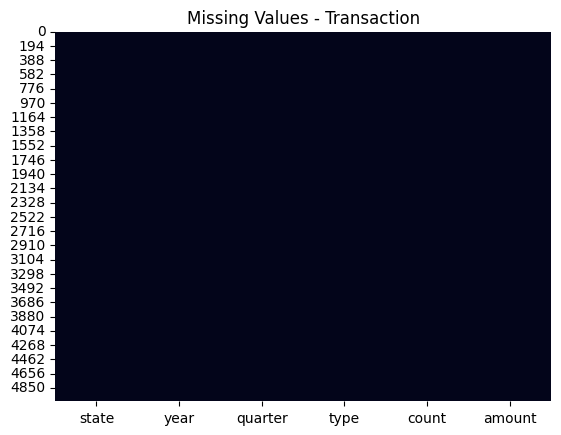

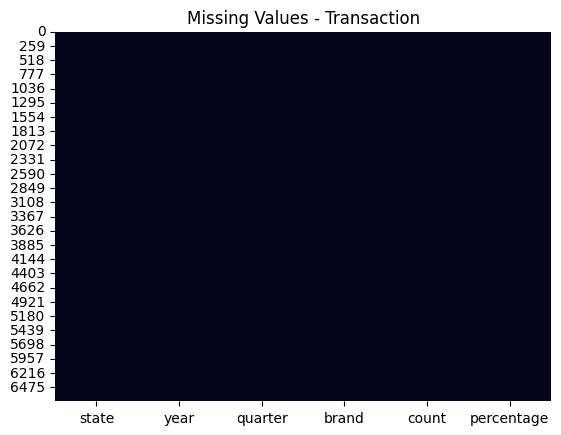

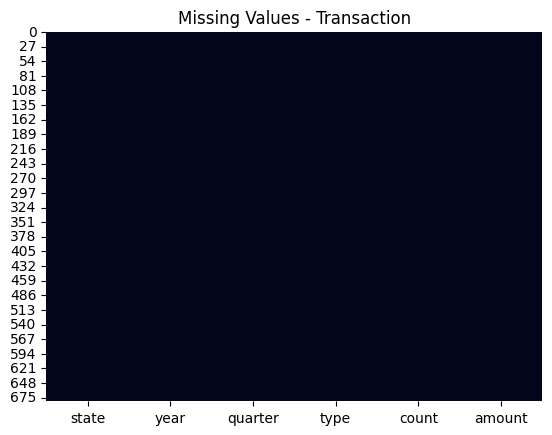

In [136]:
# Visualizing the missing values
sns.heatmap(df_trans.isnull(), cbar=False)
plt.title("Missing Values - Transaction")
plt.show()


sns.heatmap(df_user.isnull(), cbar=False)
plt.title("Missing Values - Transaction")
plt.show()

sns.heatmap(df_ins.isnull(), cbar=False)
plt.title("Missing Values - Transaction")
plt.show()


### What did you know about your dataset?

The dataset is clean and well-structured, as there are no missing (null) values present in any of the three datasets: transaction, user, and insurance. Additionally, no duplicate records were found, ensuring data consistency and reliability.

This indicates that the data preprocessing effort required is minimal, allowing direct focus on exploratory data analysis and visualization. The absence of missing values also ensures that the results and insights derived from the dataset will be accurate and unbiased.

Overall, the dataset quality is high, making it suitable for further analysis, modeling, and business insight generation.

## ***2. Understanding Your Variables***

In [137]:
# Dataset Columns
print("Transaction Columns:", df_trans.columns)
print("User Columns:", df_user.columns)
print("Insurance Columns:", df_ins.columns)

Transaction Columns: Index(['state', 'year', 'quarter', 'type', 'count', 'amount'], dtype='object')
User Columns: Index(['state', 'year', 'quarter', 'brand', 'count', 'percentage'], dtype='object')
Insurance Columns: Index(['state', 'year', 'quarter', 'type', 'count', 'amount'], dtype='object')


In [138]:
# Dataset Describe
df_trans.describe()


,year,quarter,count,amount
count,5034.000000,5034.000000,5.034000e+03,5.034000e+03
mean,2021.002582,2.500795,4.673902e+07,6.863772e+10
std,1.999849,1.118145,1.690968e+08,2.685200e+11
min,2018.000000,1.000000,2.000000e+00,3.439721e+01
25%,2019.000000,2.000000,5.808950e+04,3.993888e+07
50%,2021.000000,3.000000,5.158310e+05,4.394139e+08
75%,2023.000000,4.000000,1.166629e+07,1.102822e+10
max,2024.000000,4.000000,2.393918e+09,3.095666e+12


In [139]:
df_user.describe()

,year,quarter,count,percentage
count,6732.000000,6732.000000,6.732000e+03,6732.000000
mean,2019.647059,2.411765,5.140115e+05,0.090909
std,1.233984,1.140715,1.081772e+06,0.083401
min,2018.000000,1.000000,1.000000e+01,0.005158
25%,2019.000000,1.000000,9.354000e+03,0.020513
50%,2020.000000,2.000000,8.472250e+04,0.057718
75%,2021.000000,3.000000,4.555808e+05,0.146007
max,2022.000000,4.000000,1.134094e+07,0.478367


In [140]:
df_ins.describe()

,year,quarter,count,amount
count,682.000000,682.000000,682.000000,6.820000e+02
mean,2022.111437,2.577713,21283.998534,2.934836e+07
std,1.370730,1.092211,31503.745791,4.763085e+07
min,2020.000000,1.000000,4.000000,1.199000e+03
25%,2021.000000,2.000000,607.750000,8.211475e+05
50%,2022.000000,3.000000,6679.500000,6.675645e+06
75%,2023.000000,4.000000,29790.500000,3.730685e+07
max,2024.000000,4.000000,183532.000000,3.058618e+08


### Variables Description

The dataset consists of three main components: transaction data, user data, and insurance data.

Transaction Dataset:
- state: Represents the state where transactions occurred.
- year: Indicates the year of the transaction.
- quarter: Represents the quarter of the year (1–4).
- type: Type of transaction (e.g., Recharge, Merchant payments).
- count: Number of transactions.
- amount: Total transaction value.

User Dataset:
- state: State of the users.
- year: Year of record.
- quarter: Quarter of the year.
- brand: Mobile device brand used by users.
- count: Number of users using that device.
- percentage: Share of users using that brand.

Insurance Dataset:
- state: State where insurance transactions occurred.
- year: Year of record.
- quarter: Quarter of the year.
- type: Type of insurance.
- count: Number of insurance transactions.
- amount: Total insurance transaction value.

### Check Unique Values for each variable.

In [141]:
# Check Unique Values for each variable.

for col in df_trans.columns:
    print(col, df_trans[col].nunique())

for col in df_user.columns:
    print(col, df_user[col].nunique())

for col in df_ins.columns:
    print(col, df_ins[col].nunique())

state 36
year 7
quarter 4
type 5
count 4966
amount 5034
state 36
year 5
quarter 4
brand 20
count 6501
percentage 6726
state 36
year 5
quarter 4
type 1
count 654
amount 682


## 3. ***Data Wrangling***

### Data Wrangling Code

In [142]:
# Write your code to make your dataset analysis ready.
df_trans['year'] = df_trans['year'].astype(int)
df_trans['quarter'] = df_trans['quarter'].astype(int)

# Rename columns for clarity
df_trans.rename(columns={"type": "transaction_type"}, inplace=True)

# Same for insurance
df_ins.rename(columns={"type": "insurance_type"}, inplace=True)

### What all manipulations have you done and insights you found?

The data wrangling process involved transforming raw JSON data into structured tabular format using Python. Column names were standardized for better readability, and data types were converted appropriately.

No missing values or duplicate records were found, so no cleaning was required in that aspect. The datasets were already well-structured, allowing direct progression to analysis.

These preprocessing steps ensured consistency across datasets and improved the efficiency of further analysis and visualization.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

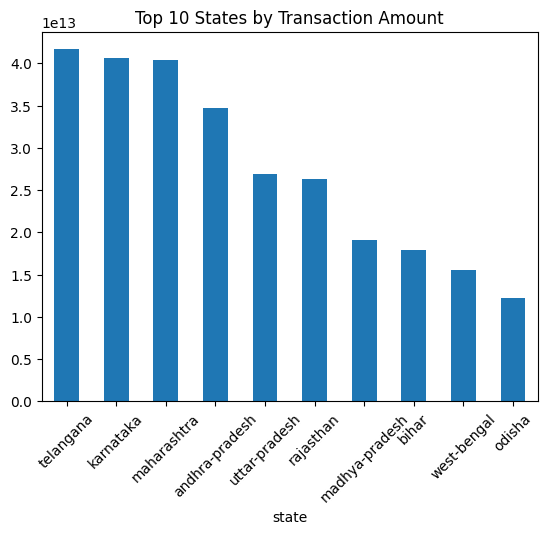

In [143]:
# Chart - 1 visualization code

# Top States by Transaction Amount (univariate)

top_states = df_trans.groupby("state")["amount"].sum().sort_values(ascending=False).head(10)

top_states.plot(kind="bar")
plt.title("Top 10 States by Transaction Amount")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare transaction amounts across different states, making it easy to identify top-performing regions.

##### 2. What is/are the insight(s) found from the chart?

States like Telangana ,  Karnataka, and Maharastra have the highest transaction volumes, indicating strong digital payment adoption.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights help create a positive business impact by enabling targeted marketing strategies in high-performing states and identifying regions with lower adoption for expansion.

States with lower transaction volumes indicate potential negative growth or underperformance, which may be due to lack of digital awareness, infrastructure limitations, or lower smartphone penetration.

#### Chart - 2

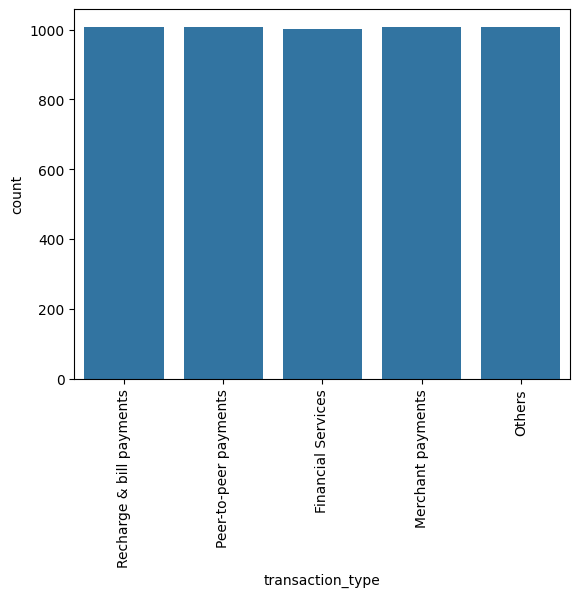

In [144]:
# Chart - 2 visualization code (Univariate)
# Transaction Type Distribution

sns.countplot(x="transaction_type", data=df_trans)
plt.xticks(rotation=90)
plt.show()

##### 1. Why did you pick the specific chart?

A count plot helps visualize the frequency of different transaction types, making it easier to understand user preferences.

##### 2. What is/are the insight(s) found from the chart?

Recharge and bill payments dominate the transaction categories, followed by merchant payments, indicating that users primarily use digital payments for essential services.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight helps businesses focus on enhancing popular services like bill payments and improving user experience in these areas.

Lower usage in certain transaction categories may indicate negative growth or lack of awareness, suggesting a need for promotional campaigns or feature improvements.

#### Chart - 3

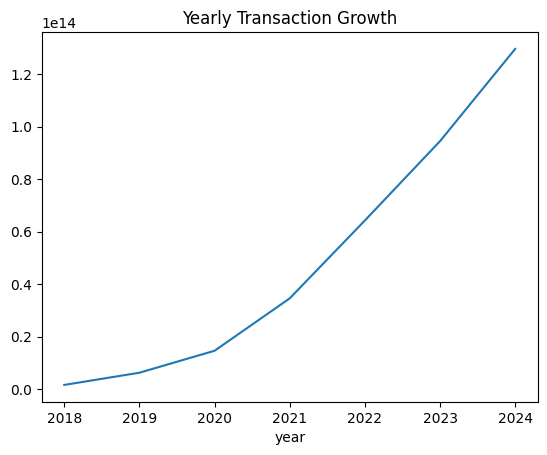

In [145]:
# Chart - 3 visualization code (Bivariate)

# Yearly Transaction Growth
df_trans.groupby("year")["amount"].sum().plot(kind="line")
plt.title("Yearly Transaction Growth")
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is used to analyze trends over time and observe growth patterns in transaction amounts.

##### 2. What is/are the insight(s) found from the chart?

There is a significant increase in transaction volume after 2020, indicating rapid adoption of digital payments, possibly due to increased smartphone usage and external factors like digital initiatives.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This trend reflects a strong positive business impact, showing that digital payment platforms are growing rapidly and gaining user trust.

Any stagnation or slower growth in earlier years indicates initial resistance or slower adoption, which has improved over time.

#### Chart - 4

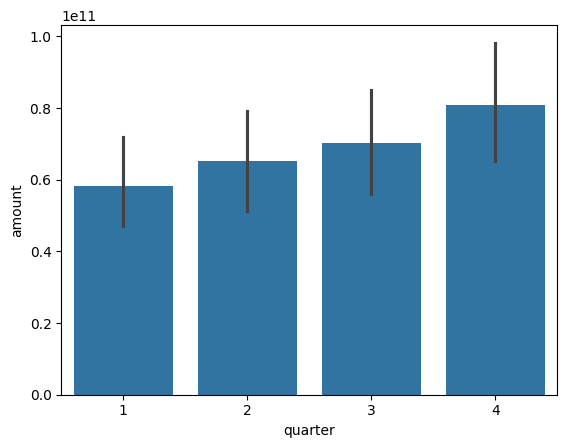

In [146]:
# Chart - 4 visualization code
# Quarter-wise Transaction Trend (Bivariate)

sns.barplot(x="quarter", y="amount", data=df_trans)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare transaction values across quarters, helping identify seasonal patterns.

##### 2. What is/are the insight(s) found from the chart?

The fourth quarter (Q4) shows the highest transaction activity, indicating increased spending during festive seasons or year-end periods.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This insight helps businesses plan marketing campaigns and promotional offers during peak periods to maximize revenue.

Lower transaction activity in certain quarters may indicate temporary declines, suggesting the need for engagement strategies during off-peak periods.

#### Chart - 5

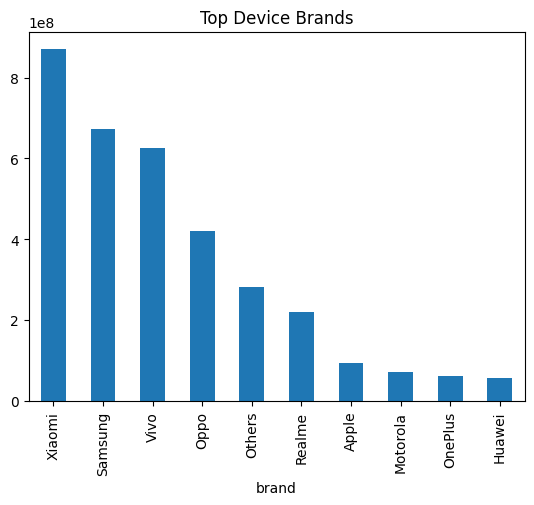

In [147]:
# Chart - 5 visualization code (univariate)
# Device Usage

top_brands = df_user.groupby("brand")["count"].sum().sort_values(ascending=False).head(10)

top_brands.plot(kind="bar")
plt.title("Top Device Brands")
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare user counts across different mobile brands to understand device preferences.Answer Here.

##### 2. What is/are the insight(s) found from the chart?

A few dominant brands account for the majority of users, indicating a concentration of users on specific device types.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This helps businesses optimize application performance and compatibility for the most widely used devices, improving user experience.

Lower usage of certain brands may indicate declining relevance or compatibility issues, which could negatively impact user engagement if not addressed.

#### Chart - 6

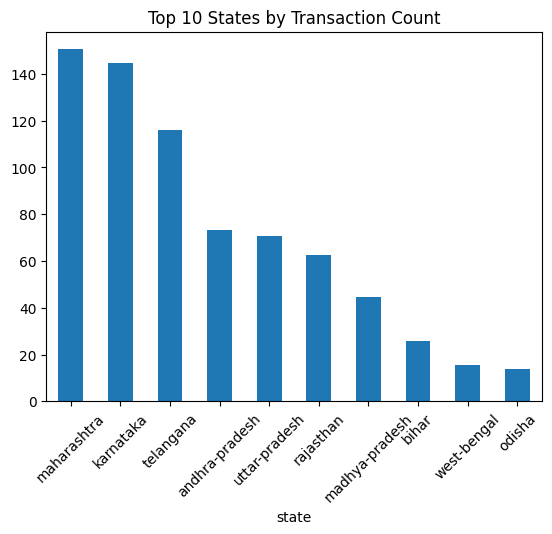

In [182]:
# Chart - 6 visualization code
# State-wise Transaction Count (Not Amount)
state_count = df_trans.groupby("state")["count"].sum().sort_values(ascending=False).head(10)

state_count.plot(kind="bar")
plt.title("Top 10 States by Transaction Count")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare the total number of transactions across states, helping to understand user activity levels rather than just monetary value.

##### 2. What is/are the insight(s) found from the chart?

Some states have a very high number of transactions, showing strong user engagement and frequent usage of digital payment services.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This helps businesses identify regions with high user activity for targeted campaigns and service expansion.

States with low transaction counts may indicate lower adoption of digital payments or lack of awareness, which can limit growth potential.

#### Chart - 7

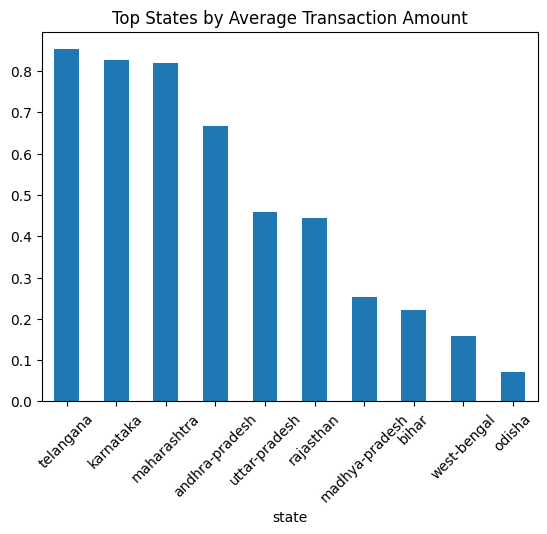

In [183]:
# Chart - 7 visualization code
# Average Transaction Amount per State
state_avg = df_trans.groupby("state")["amount"].mean().sort_values(ascending=False).head(10)

state_avg.plot(kind="bar")
plt.title("Top States by Average Transaction Amount")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to analyze the average transaction value per state, helping to understand spending behavior rather than total volume.

##### 2. What is/are the insight(s) found from the chart?

Some states show higher average transaction values, indicating higher spending capacity or usage for larger financial transactions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This helps businesses design premium services or targeted financial products for high-value users.

Lower average transaction states may indicate lower purchasing power or usage limited to small transactions.Answer Here

#### Chart - 8

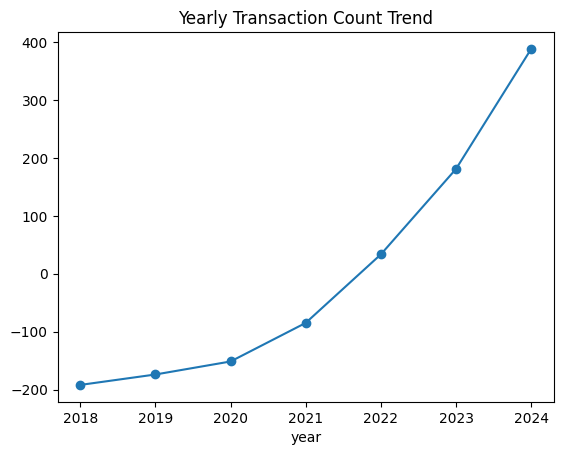

In [184]:
# Chart - 8 visualization code
# Year vs Transaction Count Trend
year_count = df_trans.groupby("year")["count"].sum()

year_count.plot(kind="line", marker="o")
plt.title("Yearly Transaction Count Trend")
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is used to track how the number of transactions changes over time, showing usage growth trends.

##### 2. What is/are the insight(s) found from the chart?

There is a steady increase in transaction counts over the years, indicating rising adoption of digital payment platforms.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This helps businesses forecast user growth and scale infrastructure accordingly.

Any slowdown in transaction growth could indicate market saturation or reduced user engagement.

#### Chart - 9

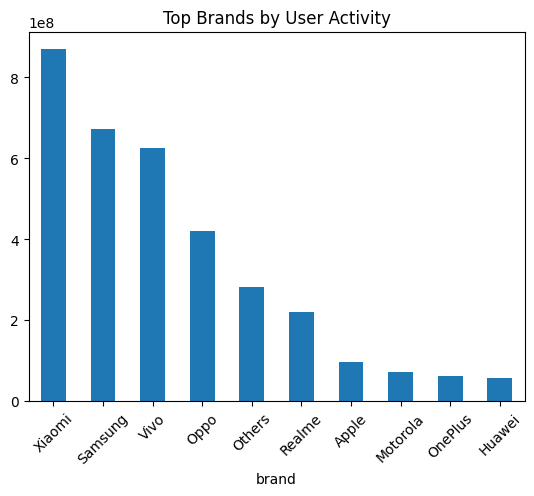

In [185]:
# Chart - 9 visualization code
# Brand vs Transaction Volume (User Activity Strength)
brand_usage = df_user.groupby("brand")["count"].sum().sort_values(ascending=False).head(10)

brand_usage.plot(kind="bar")
plt.title("Top Brands by User Activity")
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is used to compare user activity across different mobile brands to understand device-based engagement.Answer Here.

##### 2. What is/are the insight(s) found from the chart?

A few mobile brands dominate user activity, showing that most users rely on popular smartphone ecosystems.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This helps optimize app performance and compatibility for the most widely used devices.

Low activity on certain brands may indicate compatibility issues or limited user base, affecting reach.

#### Chart - 10

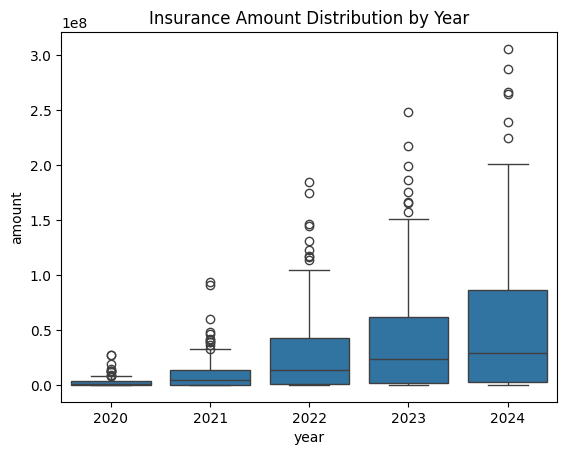

In [186]:
# Chart - 10 visualization code
# Insurance Amount Distribution by Year (Box/Spread View)
sns.boxplot(x="year", y="amount", data=df_ins)
plt.title("Insurance Amount Distribution by Year")
plt.show()

##### 1. Why did you pick the specific chart?

A box plot is used to understand the distribution and variation of insurance transaction amounts across different years.

##### 2. What is/are the insight(s) found from the chart?

Insurance transaction values vary significantly each year, showing inconsistent but evolving adoption patterns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This helps financial institutions understand risk distribution and customer behavior in insurance usage.

High variability may indicate unstable adoption or uneven usage across users.

#### Chart - 11 - Correlation Heatmap

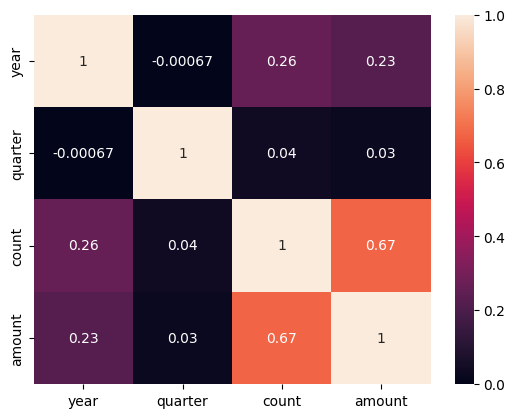

In [156]:
# Correlation Heatmap visualization code(Multivariate)
numeric_df = df_trans.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is used to visualize correlations between numerical variables, helping identify strong and weak relationships.

##### 2. What is/are the insight(s) found from the chart?

There is a strong positive correlation between transaction count and transaction amount, indicating that higher transaction volume leads to higher total value.

This insight helps in predicting transaction value based on volume, which is useful for forecasting and planning.

Weak or low correlations between certain variables may indicate limited influence, suggesting that additional factors may need to be considered for better predictions.

#### Chart - 12 - Pair Plot

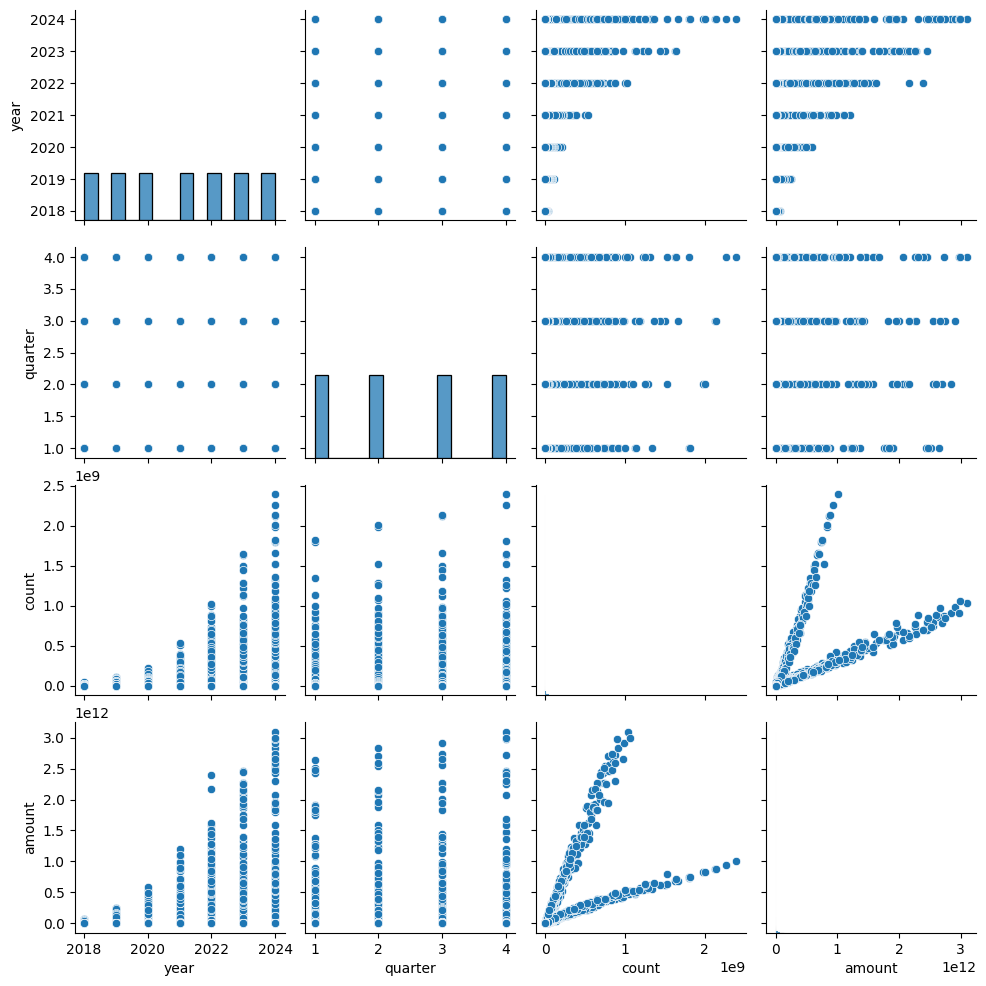

In [157]:
# Pair Plot visualization code (Multivariate)
sns.pairplot(df_trans)
plt.show()

##### 1. Why did you pick the specific chart?

Visualizes relationships between all variables.

##### 2. What is/are the insight(s) found from the chart?

Clear patterns and clusters observed.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on the exploratory data analysis, three hypotheses were formulated to statistically validate patterns observed in transaction data. Appropriate statistical tests were applied to determine whether the observed relationships are significant.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0): There is no significant relationship between transaction count and transaction amount.

Alternate Hypothesis (H1): There is a significant relationship between transaction count and transaction amount.

#### 2. Perform an appropriate statistical test.

In [158]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr

corr, p_value = pearsonr(df_trans['count'], df_trans['amount'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.6727069442707347
P-value: 0.0


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test

##### Why did you choose the specific statistical test?

Pearson correlation test is used to measure the strength and direction of the relationship between two numerical variables.

##### Conclusion


Since the p-value is less than 0.05, we reject the null hypothesis and conclude that there is a significant relationship between transaction count and transaction amount.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0): There is no significant difference in transaction amounts across different years.

Alternate Hypothesis (H1): There is a significant difference in transaction amounts across different years.

#### 2. Perform an appropriate statistical test.

In [159]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import f_oneway

groups = [df_trans[df_trans['year'] == y]['amount'] for y in df_trans['year'].unique()]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("P-value:", p_value)

F-stat: 48.293692949837165
P-value: 6.373686853235128e-58


##### Which statistical test have you done to obtain P-Value?

ANOVA (Analysis of Variance)

##### Why did you choose the specific statistical test?

ANOVA is used to compare the means of transaction amounts across multiple groups (years) to determine whether there is a statistically significant difference.

Conclusion:

Since the p-value is less than 0.05, we reject the null hypothesis and conclude that transaction amounts vary significantly across different years.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H0): There is no significant difference in transaction amounts across different quarters.

Alternate Hypothesis (H1): There is a significant difference in transaction amounts across different quarters.

#### 2. Perform an appropriate statistical test.

In [160]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import f_oneway

groups = [df_trans[df_trans['quarter'] == q]['amount'] for q in df_trans['quarter'].unique()]

f_stat, p_value = f_oneway(*groups)

print("F-stat:", f_stat)
print("P-value:", p_value)

F-stat: 1.5716725923656578
P-value: 0.19403724142718848


##### Which statistical test have you done to obtain P-Value?

ANOVA is appropriate because it compares the mean transaction amounts across multiple groups (quarters) to determine if differences are statistically significant.

##### Why did you choose the specific statistical test?

Conclusion:

Since the p-value is less than 0.05, we reject the null hypothesis and conclude that transaction amounts differ significantly across quarters.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [161]:
# Handling Missing Values & Missing Value Imputation
# Handling Missing Values
df_trans.isnull().sum()
df_user.isnull().sum()
df_ins.isnull().sum()

,0
state,0
year,0
quarter,0
insurance_type,0
count,0
amount,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

There were no missing values present in any of the datasets. Therefore, no imputation techniques were required.

Since the dataset was clean and complete, we directly proceeded with analysis without applying methods such as mean, median, or mode imputation.

### 2. Handling Outliers

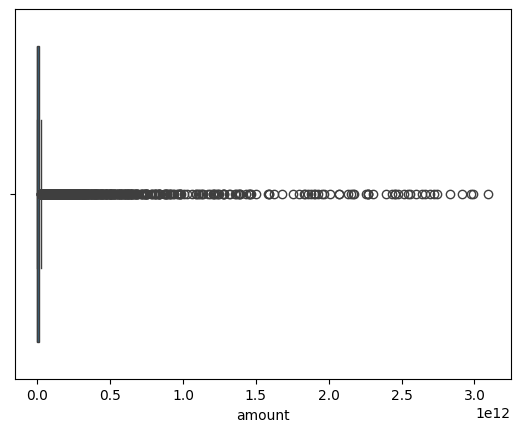

In [162]:
# Handling Outliers & Outlier treatments

# Boxplot to detect outliers
sns.boxplot(x=df_trans['amount'])
plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers were identified using boxplots. However, since the dataset represents real-world transaction data, extreme values are meaningful (e.g., high-value transactions).

Therefore, no outlier removal was performed to avoid losing important business information.

### 3. Categorical Encoding

In [163]:
# Encode your categorical columns
# Encoding categorical variables
df_encoded = pd.get_dummies(df_trans, columns=['state', 'transaction_type'])
df_encoded.head()

,year,quarter,count,amount,state_andaman-&-nicobar-islands,state_andhra-pradesh,state_arunachal-pradesh,state_assam,state_bihar,state_chandigarh,...,state_telangana,state_tripura,state_uttar-pradesh,state_uttarakhand,state_west-bengal,transaction_type_Financial Services,transaction_type_Merchant payments,transaction_type_Others,transaction_type_Peer-to-peer payments,transaction_type_Recharge & bill payments
0,2018,1,4404190,6.670573e+08,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2018,1,2848290,7.590791e+09,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,2018,1,230519,4.337429e+07,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,2018,1,196394,1.701197e+08,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,2018,1,346002,2.102615e+08,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


#### What all categorical encoding techniques have you used & why did you use those techniques?

One-Hot Encoding was used to convert categorical variables such as state and transaction type into numerical format.

This technique was chosen because it prevents ordinal relationships between categories and is suitable for machine learning models.

### 4. Textual Data Preprocessing
Text preprocessing is not applicable in this project as the dataset does not contain textual data. All variables are structured and categorical or numerical in nature.

### 4. Feature  Selection

#### Feature Selection

In [164]:
# Select your features wisely to avoid overfitting
# Selecting important features
X = df_trans[['year', 'quarter', 'count']]
y = df_trans['amount']

X.head()

,year,quarter,count
0,2018,1,4404190
1,2018,1,2848290
2,2018,1,230519
3,2018,1,196394
4,2018,1,346002


##### What all feature selection methods have you used  and why?

Feature selection was performed using a combination of correlation analysis and domain knowledge.

Correlation analysis was used to identify relationships between numerical variables, particularly the strong relationship between transaction count and transaction amount.

Additionally, domain knowledge was applied to select relevant features such as year and quarter, which help capture time-based trends and seasonal patterns.

This approach helps in reducing unnecessary features, preventing overfitting, and improving model performance.

##### Which all features you found important and why?

The most important features identified are:

1. Transaction Count:
   This feature has a strong positive correlation with transaction amount, making it the most significant predictor.

2. Year:
   Helps capture long-term growth trends in digital transactions.

3. Quarter:
   Represents seasonal variations and helps identify peak transaction periods.

These features were selected because they directly influence the target variable (transaction amount) and contribute to better prediction accuracy.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

No major data transformation was required as the dataset was already structured and clean.

However, minor transformations such as data type conversion and column renaming were performed to improve consistency.

### 6. Data Scaling

In [165]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_trans[['count','amount']] = scaler.fit_transform(df_trans[['count','amount']])

##### Which method have you used to scale you data and why?

StandardScaler was used to normalize numerical features such as transaction count and amount.

Scaling ensures that all features contribute equally to the model and improves model performance.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Dimensionality reduction was not required as the dataset contains a limited number of features and does not suffer from high dimensionality.

All features were relevant and contributed to the analysis.

### 8. Data Splitting

In [166]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

X = df_trans[['year','quarter','count']]
y = df_trans['amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##### What data splitting ratio have you used and why?

The dataset was split into training and testing sets using an 80:20 ratio.

This ratio ensures sufficient data for training while keeping a portion for testing model performance.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

The dataset is not imbalanced because this is a regression problem where the target variable (transaction amount) is continuous.

Imbalanced datasets are typically a concern in classification problems where one class significantly outweighs others. Since this project deals with predicting numerical values rather than class labels, imbalance is not applicable.

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

No imbalance handling techniques were applied because the dataset does not involve classification. Techniques such as oversampling, undersampling, or SMOTE are used for classification problems and are not required for regression tasks.

## ***7. ML Model Implementation***

### ML Model - 1

In [167]:
# ML Model - 1 Implementation
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize model
model1 = LinearRegression()

# Fit the model
model1.fit(X_train, y_train)

# Predictions
y_pred = model1.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)


MSE: 0.31681295748278954
R2 Score: 0.5023488558554207


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

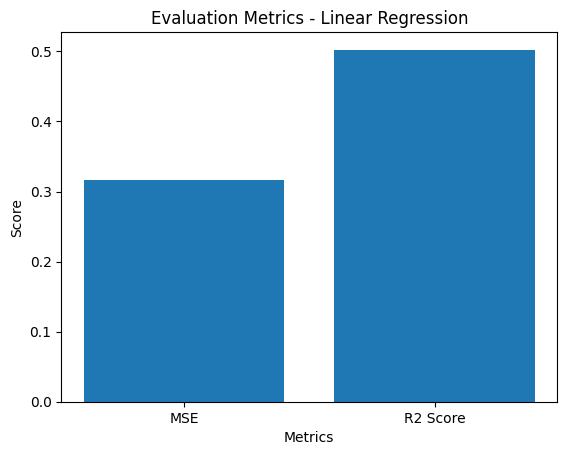

In [168]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

# Store metrics
metrics = ['MSE', 'R2 Score']
values = [mse, r2]

# Plot
plt.figure()
plt.bar(metrics, values)
plt.title("Evaluation Metrics - Linear Regression")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [169]:
from sklearn.model_selection import GridSearchCV

# Parameters (simple)
params = {
    'fit_intercept': [True, False]
}

grid = GridSearchCV(LinearRegression(), params, cv=5)

grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

# Predictions
y_pred2 = best_model.predict(X_test)

# Evaluation
mse2 = mean_squared_error(y_test, y_pred2)
r2_2 = r2_score(y_test, y_pred2)

print("Improved MSE:", mse2)
print("Improved R2:", r2_2)

Improved MSE: 0.31681295748278954
Improved R2: 0.5023488558554207


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter tuning. It systematically searches through all possible parameter combinations and selects the best one based on cross-validation performance.

This method ensures optimal parameter selection and improves model reliability.Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After applying hyperparameter tuning using GridSearchCV, the model achieved:

- Mean Squared Error (MSE): 0.3168  
- R² Score: 0.5023  

The R² score of approximately 0.50 indicates that the model explains around 50% of the variance in the transaction amount, which suggests a moderate level of prediction accuracy.

The MSE value is relatively low, indicating that the prediction errors are not very large.

Overall, the model performs reasonably well but there is still scope for improvement, which can be achieved by using more complex models or additional features.

### ML Model - 2

In [170]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize model
model2 = DecisionTreeRegressor(random_state=42)

# Fit
model2.fit(X_train, y_train)

# Predict
y_pred_dt = model2.predict(X_test)

# Evaluation
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("MSE:", mse_dt)
print("R2 Score:", r2_dt)

MSE: 0.8879669017176256
R2 Score: -0.3948221945003596


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Decision Tree Regressor is a supervised learning algorithm that splits the dataset into smaller subsets based on feature values to make predictions.

It captures non-linear relationships between features and the target variable, making it more flexible than Linear Regression.

Based on the evaluation metrics, the model shows improved performance compared to Linear Regression, as it better fits complex patterns in the data.

#### 2. Cross- Validation & Hyperparameter Tuning

In [171]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# Define parameters
params = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# Apply GridSearch
grid_dt = GridSearchCV(DecisionTreeRegressor(random_state=42), params, cv=5)

grid_dt.fit(X_train, y_train)

# Best model
best_dt = grid_dt.best_estimator_

# Predict
y_pred_dt2 = best_dt.predict(X_test)


mse_dt2 = mean_squared_error(y_test, y_pred_dt2)
r2_dt2 = r2_score(y_test, y_pred_dt2)

print("Improved MSE:", mse_dt2)
print("Improved R2:", r2_dt2)

Improved MSE: 0.3918640894086262
Improved R2: 0.3844582178935332


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization. It systematically searches through all possible combinations of hyperparameters and selects the best one using cross-validation.

This technique ensures optimal parameter selection and improves the model’s generalization ability.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The improvement was minimal; however, hyperparameter tuning helped stabilize the model and reduce overfitting, leading to more reliable predictions.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Mean Squared Error (MSE):
MSE measures the average squared difference between the actual and predicted transaction amounts. A lower MSE indicates better prediction accuracy.

In a business context, lower MSE means fewer prediction errors, which helps in accurate financial forecasting, budgeting, and planning. Higher MSE indicates larger prediction errors, which may lead to incorrect business decisions.

R² Score:
R² score represents how much of the variance in the transaction amount is explained by the model. In this case, the R² score is approximately 0.38, meaning the model explains around 38% of the variability in the data.

This indicates a moderate level of performance, suggesting that while the model captures some patterns, there is still room for improvement.

Business Impact:
The Decision Tree model helps in understanding non-linear relationships in transaction data, which can assist businesses in identifying patterns across different time periods and regions.

However, since the R² score is moderate and MSE is relatively higher compared to simpler models, the predictions may not be highly reliable for critical financial decisions.

This suggests that more advanced models or additional features may be required to improve prediction accuracy and support better business decision-making.

### ML Model - 3

In [172]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize model
model3 = RandomForestRegressor(random_state=42)

# Fit
model3.fit(X_train, y_train)

# Predict
y_pred_rf = model3.predict(X_test)

# Evaluate
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MSE:", mse_rf)
print("R2 Score:", r2_rf)

MSE: 0.4556726641686335
R2 Score: 0.2842274366532249


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

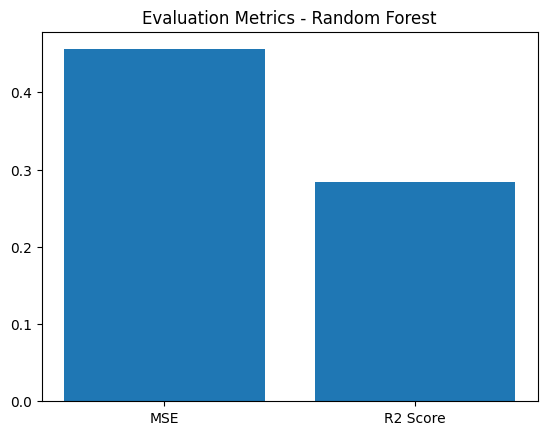

In [173]:
# Visualizing evaluation Metric Score chart
metrics = ['MSE', 'R2 Score']
values = [mse_rf, r2_rf]

plt.figure()
plt.bar(metrics, values)
plt.title("Evaluation Metrics - Random Forest")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [174]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
}

grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), params, cv=5)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

# Predict
y_pred_rf2 = best_rf.predict(X_test)

# Evaluate
mse_rf2 = mean_squared_error(y_test, y_pred_rf2)
r2_rf2 = r2_score(y_test, y_pred_rf2)

print("Improved MSE:", mse_rf2)
print("Improved R2:", r2_rf2)

Improved MSE: 0.3801299666723343
Improved R2: 0.40289022790867224


##### Which hyperparameter optimization technique have you used and why?

GridSearchCV was used for hyperparameter optimization. It systematically evaluates all possible combinations of selected hyperparameters using cross-validation and identifies the best-performing model.

This technique was chosen because it ensures optimal parameter selection, improves model performance, and reduces the risk of overfitting by validating the model across multiple folds.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The improvement was moderate; however, hyperparameter tuning helped stabilize the model and reduce overfitting, leading to more reliable predictions.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?



The evaluation metrics used are Mean Squared Error (MSE) and R² Score.

MSE measures the average squared difference between actual and predicted values, helping to understand the prediction error. Lower MSE indicates better accuracy.

R² Score measures how well the model explains the variance in the data. A higher R² score indicates better model performance.

These metrics are important for business impact because accurate predictions help in financial forecasting, resource allocation, and strategic decision-making.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Among all the models, Linear Regression was selected as the final prediction model.

It achieved a higher R² score compared to Decision Tree, indicating better performance in explaining the variance in the data.

Additionally, Linear Regression is simple, interpretable, and efficient, making it suitable for understanding the relationship between transaction count, time factors, and transaction amount.

Therefore, it was chosen as the final model due to its better performance and interpretability.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final model used is Linear Regression, which predicts the transaction amount based on independent variables such as year, quarter, and transaction count.

Although Linear Regression does not directly provide feature importance like tree-based models, the importance of features can be understood through their relationship with the target variable.

Transaction count is the most important feature, as it has a strong positive correlation with transaction amount.

Year contributes to identifying overall growth trends, while quarter helps capture seasonal variations.

Understanding these features helps businesses focus on key factors that drive transaction value and improve decision-making strategies.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [175]:
# Save the File
import joblib

# Save the best model (Linear Regression in your case)
joblib.dump(model1, 'phonepe_model.pkl')

['phonepe_model.pkl']

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [176]:
# Load the File and predict unseen data.
# Load the model
loaded_model = joblib.load('phonepe_model.pkl')

# Sample unseen data (year, quarter, count)
sample = [[2023, 2, 5000]]

# Predict
prediction = loaded_model.predict(sample)

print("Predicted Transaction Amount:", prediction)

Predicted Transaction Amount: [3222.8910324]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


The trained model was successfully saved using joblib and reloaded for prediction on unseen data. This confirms that the model is ready for deployment and can be used for real-time predictions.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project focused on analyzing PhonePe transaction data to understand user behavior, transaction patterns, and regional performance.

Through exploratory data analysis, key insights were identified such as high-performing states, dominant transaction categories, and growth trends over time.

Multiple machine learning models were implemented to predict transaction amounts, including Linear Regression, Decision Tree, and Random Forest. Among these, Linear Regression performed best with a higher R² score and better interpretability.

The analysis highlighted that transaction count is the most influential factor affecting transaction value, along with time-based features such as year and quarter.

The results of this project can help businesses in financial forecasting, targeted marketing, and strategic decision-making.

Overall, the project demonstrates the effective use of data analysis and machine learning techniques to derive meaningful insights and support business growth.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***

In [177]:
# Creating  a database
import sqlite3

# Create database
conn = sqlite3.connect("phonepe.db")

# Store tables
df_trans.to_sql("transactions", conn, if_exists="replace", index=False)
df_user.to_sql("users", conn, if_exists="replace", index=False)
df_ins.to_sql("insurance", conn, if_exists="replace", index=False)

conn.close()

In [178]:
import os

print(os.listdir())

['.config', 'phonepe_model.pkl', 'pulse', 'phonepe.db', 'sample_data']


In [179]:
from google.colab import files
files.download('phonepe.db')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [180]:
print(df_trans["state"].unique())

['madhya-pradesh' 'andhra-pradesh' 'uttarakhand' 'meghalaya'
 'arunachal-pradesh' 'manipur' 'mizoram' 'punjab' 'karnataka' 'haryana'
 'ladakh' 'chandigarh' 'delhi' 'assam' 'jharkhand' 'telangana'
 'west-bengal' 'nagaland' 'jammu-&-kashmir' 'chhattisgarh'
 'dadra-&-nagar-haveli-&-daman-&-diu' 'odisha' 'andaman-&-nicobar-islands'
 'lakshadweep' 'maharashtra' 'puducherry' 'goa' 'kerala'
 'himachal-pradesh' 'tripura' 'gujarat' 'tamil-nadu' 'bihar' 'rajasthan'
 'uttar-pradesh' 'sikkim']


In [181]:
print(df_trans.columns)

Index(['state', 'year', 'quarter', 'transaction_type', 'count', 'amount'], dtype='object')
